In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from astropy.time import Time
import matplotlib as mpl
import seaborn as sns
from cycler import cycler
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from glob import glob
from astropy.table import Table
from astropy.visualization import quantity_support
import astropy.constants as const
import astropy.units as u

#Source - https://stackoverflow.com/a/64464889 <br>
#Posted by Rafael Ferro, modified by community. See post 'Timeline' for change history <br>
#Retrieved 2026-04-16, License - CC BY-SA 4.0 <br>

sudo apt install texlive texlive-latex-extra texlive-fonts-recommended dvipng cm-super <br>


#Source - https://stackoverflow.com/a/64464889 <br>
#Posted by Rafael Ferro, modified by community. See post 'Timeline' for change history <br>
#Retrieved 2026-04-16, License - CC BY-SA 4.0 <br>

pip install latex

In [29]:
quantity_support()
clrs = sns.color_palette('Set1')
clrs[5] = (255/255, 200/255, 80/255)
clrs[0], clrs[1] = clrs[1], clrs[0]
color_cycle = cycler('color', list(clrs.as_hex()))
mpl.rc('font', family='serif')
mpl.rc('text', usetex=True)
mpl.rc('axes', labelsize=15)

plt.rc('axes', axisbelow=True, 
       grid=False, prop_cycle=color_cycle)
plt.rc('xtick', direction='in')
plt.rc('ytick', direction='in')
plt.rcParams['figure.dpi'] = 150

In [3]:
aavso_path = os.path.join('data', 'observations_20260401_RU_Lup','RULupi_AAVSOobservations_20260401_153150.csv')
aavso_points = pd.read_csv(aavso_path)
aavso_points.keys()

Index(['#', 'target', 'auid', 'jd', 'mag', 'uncertainty', 'fainterthan',
       'band', 'type', 'observer', 'airmass', 'transformed'],
      dtype='object')

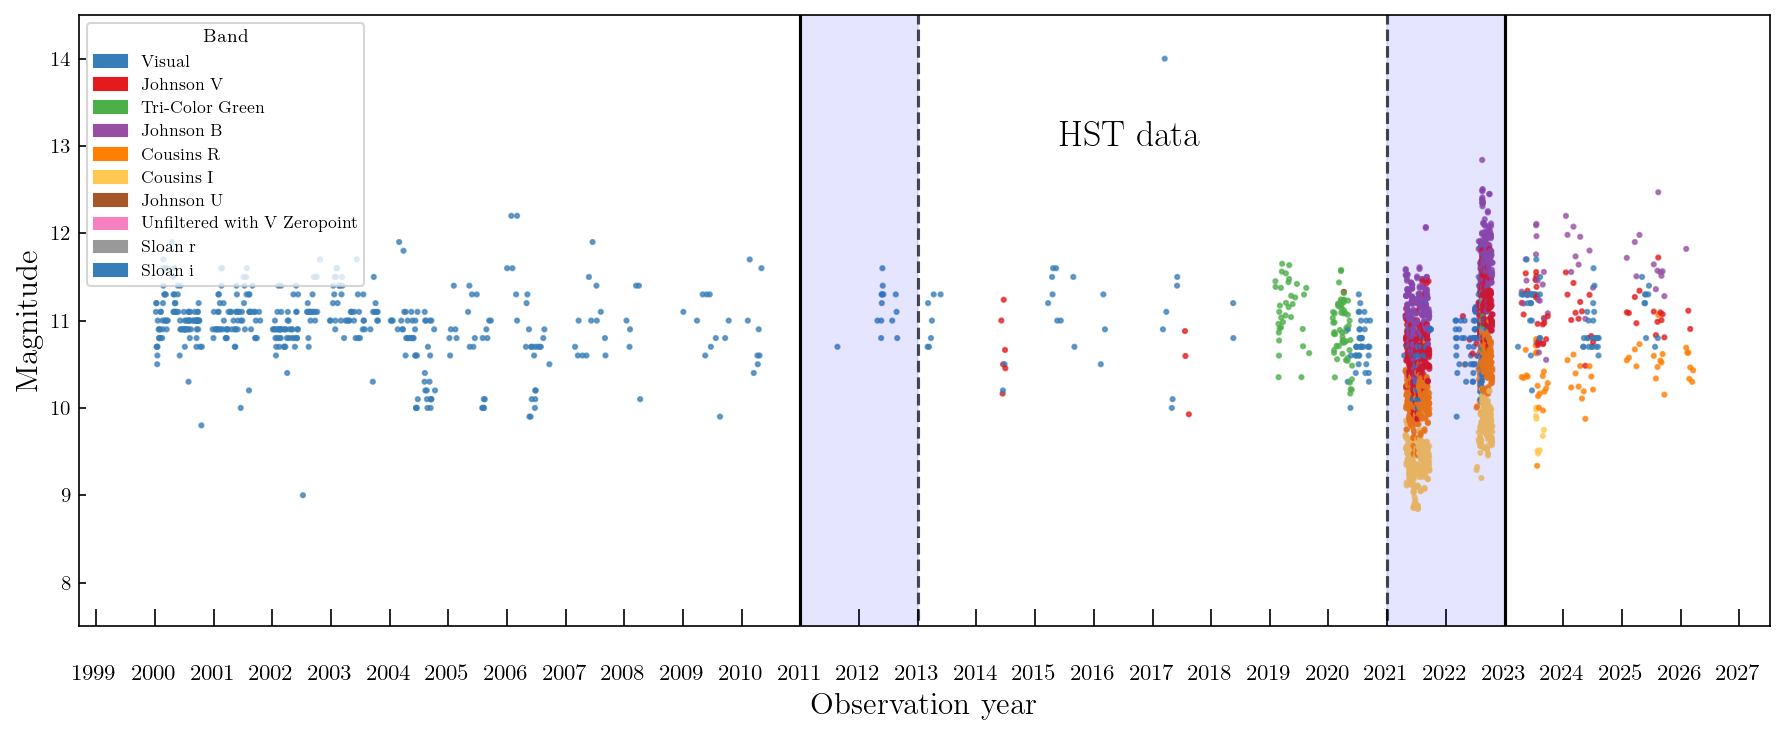

In [30]:
aavso_jd = Time(aavso_points['jd'], format='jd')
x = np.array(aavso_jd.to_value('iso'), dtype='datetime64[D]')

# Map each band to a color
unique_bands = aavso_points['band'].unique()
hex_colors = list(clrs.as_hex())
band_color_map = {band: hex_colors[i % len(hex_colors)] for i, band in enumerate(unique_bands)}
colors = [band_color_map[b] for b in aavso_points['band']]

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(x, aavso_points['mag'], s=4, c=colors, alpha=0.7)

ax.set_ylim(7.5, 14.5)
ax.set_ylabel('Magnitude')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.tick_params(axis='x', which='major', labelsize=11, pad=18, length=8)
ax.set_xlabel('Observation year')

ax.vlines(np.array(['2011', '2023'], dtype='datetime64[D]'), 7,15, 'black')
ax.vlines(np.array(['2013', '2021'], dtype='datetime64[D]'), 7,15, 'black', '--', alpha=0.7)
ax.fill_between(np.array(['2011', '2013'], dtype='datetime64[D]'), 7,15, alpha=0.1, color='blue')
ax.fill_between(np.array(['2021', '2023'], dtype='datetime64[D]'), 7,15, alpha=0.1, color='blue')
ax.text(np.array(['2015-06-01'], dtype='datetime64[D]'), 13, 'HST data', size='xx-large')

legend_handles = [mpatches.Patch(color=band_color_map[band], label=band) for band in unique_bands]

ax.legend(handles=legend_handles, title='Band', loc='upper left',
          fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig('images/AAVSO_RULup.pdf')
plt.show()

In [5]:
#get the lines from me:
line_df = pd.read_pickle(os.path.join('data', 'line_df_coadded_bootstrapped_run2.pkl'))
blue_df = pd.read_pickle(os.path.join('data', 'blue_df_coadded_bootstrapped_run2.pkl'))
red_df = pd.read_pickle(os.path.join('data', 'red_df_coadded_bootstrapped_run2.pkl'))

all_df = pd.concat([blue_df, line_df, red_df])

def SNR(signal, noise):
    return np.mean(signal/noise)

def snr_mask(df, low, high):
    ratio = df.apply(lambda r: SNR(r['gauss_flux'], r['gauss_fluxerr']) /
                               SNR(r['flux'], r['fluxerr']), axis=1)
    return df[ratio.between(low, high)]

def peak_mask(df, thresh):
    ratio = df.apply(lambda r: max(r['gauss_flux'].value)/r['params1']['bgl'][0], axis=1)
    mask = np.array(ratio) > thresh
    return ratio, df[mask].copy()

#Drop lines with low peak-significance
_, red_df_peak  = peak_mask(snr_mask(red_df,  1.5, 13),  1.5)
_, blue_df_peak = peak_mask(snr_mask(blue_df, 1.5, 16), 1.5)
_, line_df_peak = peak_mask(snr_mask(line_df, 0.8, 100), 1.5)

all_df_pruned = pd.concat([blue_df_peak, line_df_peak, red_df_peak])

del line_df, blue_df, red_df, red_df_peak, blue_df_peak, line_df_peak

my_lablines = all_df_pruned['labline'].unique()

In [6]:
linelist_file = os.path.join('HST','emission_lines.csv')
linelist = pd.read_csv(linelist_file, skiprows=2)
transitions = []
rows = []
for l in my_lablines:
    transitions.append(linelist["[nu', J']"][linelist['lab_lambda']==l].values[0])
    rows.append(linelist[linelist['lab_lambda']==l].values[0])

print(linelist.keys())
print(rows)

Index(['Line ID', '[nu', J']', 'lab_lambda', 'transition_prob', 'pump_lambda'], dtype='object')
[array(['(4–11)P(5)', '[4,4]', 1613.72, 0.15, 1214.78], dtype=object), array(['(4–6)R(12)', '[4,13]', 1415.33, 0.037, 1213.68], dtype=object), array(['(0–6)P(3)', '[0,2]', 1463.83, 0.074, 1217.64], dtype=object), array(['(0–6)P(2)', '[0,1]', 1460.17, 0.083, 1217.21], dtype=object), array(['(0–5)P(2)', '[0,1]', 1398.95, 0.141, 1217.21], dtype=object), array(['(0–2)P(2)', '[0,1]', 1521.59, 0.032, 1217.21], dtype=object), array(['(1–6)R(3)', '[1,4]', 1431.01, 0.058, 1216.07], dtype=object), array(['(1–6)P(5)', '[1,4]', 1446.12, 0.083, 1216.07], dtype=object), array(['(1–7)R(3)', '[1,4]', 1489.57, 0.094, 1216.07], dtype=object), array(['(1–7)P(5)', '[1,4]', 1504.76, 0.115, 1216.07], dtype=object), array(['(1–6)P(8)', '[1,7]', 1467.08, 0.08, 1215.73], dtype=object), array(['(1–7)R(6)', '[1,7]', 1500.45, 0.101, 1215.73], dtype=object), array(['(3–11)P(1)', '[3,0]', 1636.34, 0.099, 1217.04], dtype=

In [7]:
pk_lines = [(trans, lines) for trans, lines in zip(transitions, my_lablines)]

In [8]:
#calvet lines:
calvet_lines = {'Si IV': 1394,
                'Si IV (2)': 1403,
                'C I': 1463,
                'Mg II': 1466.55,
                'C IV': 1548,
                'Fe II': 1602}

In [9]:
spectrum_files = glob(os.path.join('HST','anonymous37222', '*x1dsum.fits'))
spec = Table.read(spectrum_files[4])
wave = np.concatenate(spec['WAVELENGTH'].value)
flux = np.concatenate(spec['FLUX'].value)

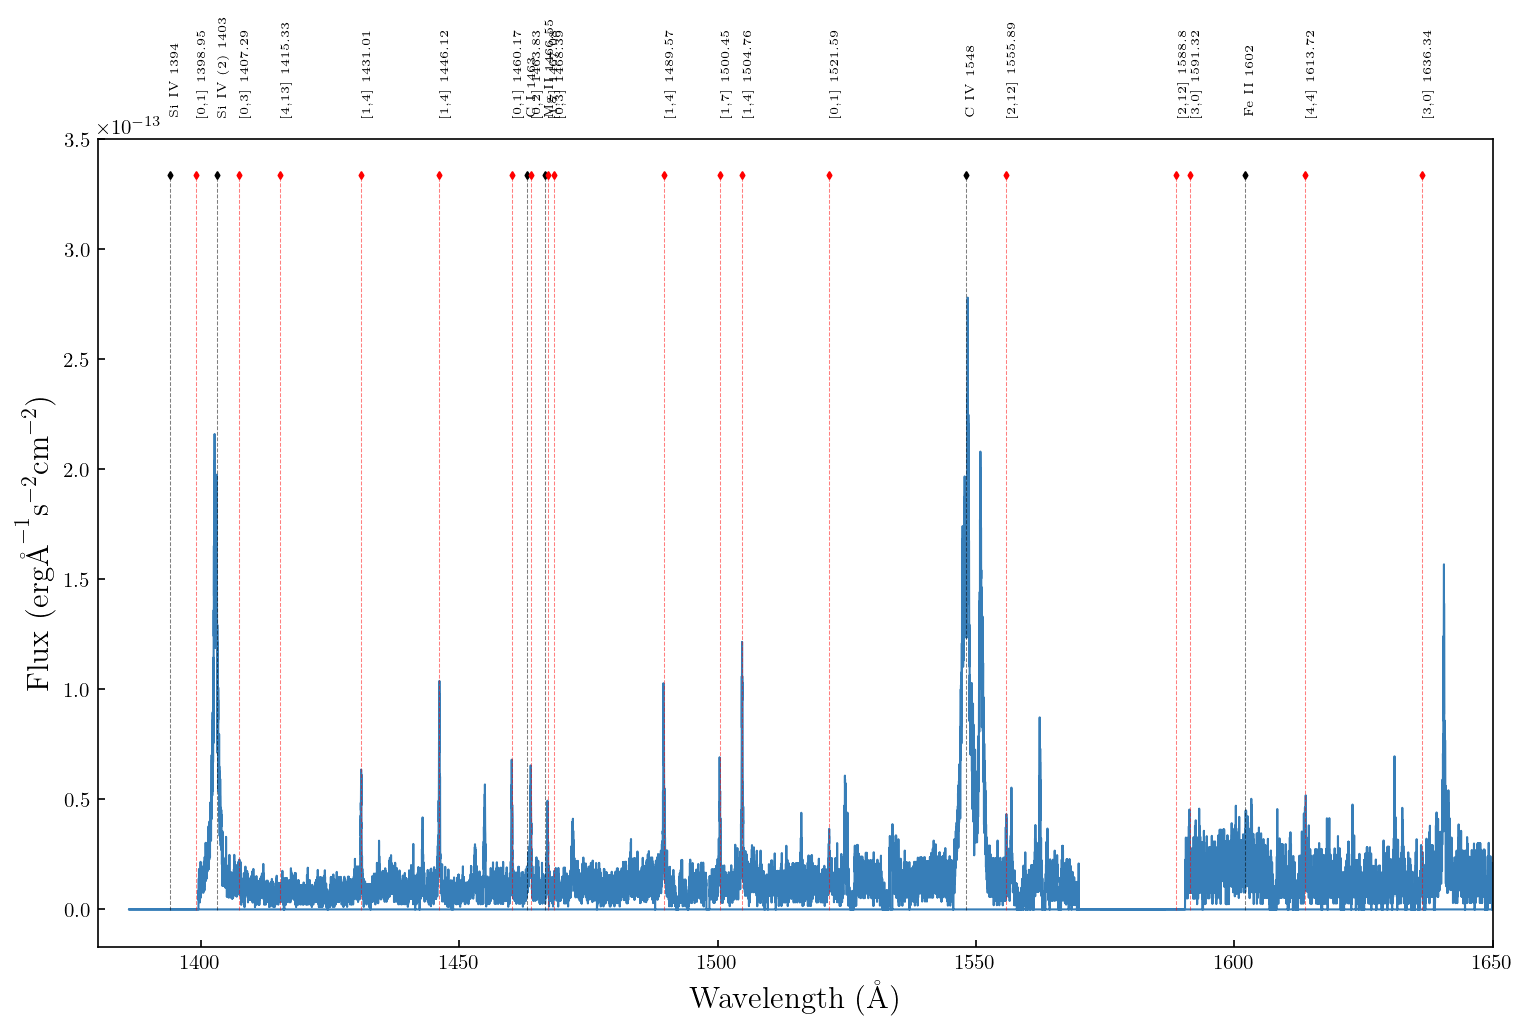

In [31]:
#full spectrum + contaminants
fig, ax = plt.subplots(figsize=(12,7))
ax.plot(wave, flux, c=clrs[0], lw=1)
for key, value in calvet_lines.items():
    ax.vlines(value, min(flux), max(flux)*1.2, 'black', '--', alpha=0.5, lw=0.5)
    ax.scatter(value, [max(flux)*1.2], marker='d', c='black', s=5)
    ax.text(value, (max(flux)*1.3), key+' '+str(value), size='xx-small', rotation='vertical')

for key, value in pk_lines:
    ax.vlines(value, min(flux), max(flux)*1.2, 'red', '--', alpha=0.5, lw=0.5)
    ax.scatter(value, max(flux)*1.2, marker='d', c='red', s=5)
    ax.text(value, (max(flux)*1.3), key+' '+str(value), size='xx-small', rotation='vertical')

ax.set_ylabel(r'Flux (erg$ \mathrm{\AA}^{-1} \textrm{s}^{-2} \textrm{cm}^{-2}$)')
ax.set_xlabel(r'Wavelength ($\mathrm{\AA}$)')
ax.set_xlim(1380, 1650)
plt.savefig('images/emission_spectrum.pdf')
plt.show()

In [38]:
def radial_velocity(wavelengths, labline):
    velocity = (wavelengths - labline*u.AA)/(labline*u.AA) * const.c.to(u.km/u.s)
    vsini = velocity#/np.sin(np.radians(16))
    return vsini

def mask_contamination(labline, mask_dict):
    mask_idx = mask_dict[labline]
    if isinstance(mask_idx, list):
        mask=np.ones(300, dtype=bool)
        mask[mask_idx[0]:mask_idx[1]] = False
        return mask
    else:
        mask=np.zeros(300, dtype=bool)
        mask[mask_idx:] = True
        return mask
    
def gaussian(x, amp, sig, cen, bgl):
    x = np.array(x)
    y = amp * np.exp(-((x - cen)**2.0)/(2.0 * (sig**2.0))) + bgl
    return y

def make_gauss_from_params(x, params):
    if len(params) == 4:
        return gaussian(x, params['amp'][0], params['sig'][0], params['cen'][0], params['bgl'][0])
    if len(params) == 7:
        return [gaussian(x, params['amp1'][0], params['sig1'][0], params['cen1'][0], params['bgl'][0]), gaussian(x, params['amp2'][0], params['sig2'][0], params['cen2'][0], params['bgl'][0])]
        
# labline: mask array
line_mask_dict = {
    1453.1:200,
    1555.89:[75,175],
    1463.83:200,
    1613.72:[75,200],
    1415.33:180,
    1407.29:200,
    1468.39:[75,299], #mask out MgII transition at 1466.55
    1407.29: [75,250],
    1435.05: [80,299], #High velocity component
    1636.34: [75,190]
}

def calculate_chi2(df):
    chi2_single = []
    chi2_double = []
    red_chi2_single = []
    red_chi2_double = []

    for _, row in df.iterrows():
        f_obs = np.array(row['flux'], dtype=float)
        f_err = np.array(row['fluxerr'], dtype=float)
        f_model_single = np.array(row['gauss_flux'], dtype=float)
        f_model_double = np.array(row['double_gauss_flux'], dtype=float)

        # apply mask if labline has one
        if row['labline'] in line_mask_dict.keys():
            mask = mask_contamination(row['labline'], line_mask_dict)
            f_obs = f_obs[~mask]
            f_err = f_err[~mask]

        chi2_1 = np.sum(((f_obs - f_model_single) / f_err) ** 2)
        chi2_2 = np.sum(((f_obs - f_model_double) / f_err) ** 2)
        chi2_single.append(chi2_1)
        chi2_double.append(chi2_2)

        #calculate reeduced chi2
        red_chi2_1 = chi2_1/(len(f_obs) - len(row['params1']))
        red_chi2_2 = chi2_2/(len(f_obs) - len(row['params2']))
        red_chi2_single.append(red_chi2_1)
        red_chi2_double.append(red_chi2_2)

    return red_chi2_single, red_chi2_double

def plot_fits(df, transition, plot_vel=False):
    subset = df[df['transition']==transition].reset_index(drop=True)
    #chi2 values to add to residuals plot
    chi2_1, chi2_2 = calculate_chi2(subset)
    for i, row in subset.iterrows():
        flux = row['flux'].value
        fluxerr = row['fluxerr'].value
        wave = row['wavelength']#.value
        vel_data = radial_velocity(wave, row['labline']).value
        
        ygauss = row['gauss_flux'].value
        ygausserr = row['gauss_fluxerr'].value

        y2gauss = row['double_gauss_flux'].value
        y2gausserr = row['double_gauss_fluxerr'].value
        
        waveconv = row['conv_wavelength']#.value
        vel_conv = radial_velocity(waveconv, row['labline']).value

        fig, ax = plt.subplots(2,2, figsize = (9,5), sharex=True, gridspec_kw={'height_ratios':[3,1]}, layout='constrained')
        fig.subplots_adjust(hspace=0, wspace=0)
        if plot_vel:
            #data
            ax[0,0].plot(vel_data, flux, '--', label='emission line')
            ax[0,0].fill_between(vel_data, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)
            ax[0,1].plot(vel_data, flux, '--', label='emission line')
            ax[0,1].fill_between(vel_data, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)
            
            #fits
            ygauss1, ygauss2 = make_gauss_from_params(waveconv, row['params2'])

            ax[0,0].plot(vel_conv, ygauss, label='single conv gauss')
            ax[0,0].fill_between(vel_conv, ygauss-ygausserr, ygauss+ygausserr, color='red', alpha=0.4,)

            ax[0,1].plot(vel_conv, ygauss1, label='1')
            ax[0,1].plot(vel_conv, ygauss2, label='2')

            ax[0,0].set_title(f"BIC = {row['BIC1']}")
            ax[0,1].set_title(f"BIC = {row['BIC2']}")

            ax[0,1].plot(vel_conv, y2gauss, label='double conv gauss')
            ax[0,1].fill_between(vel_conv, y2gauss-y2gausserr, y2gauss+y2gausserr, color='red', alpha=0.4,)

            #residuals
            if row['labline'] in line_mask_dict:
                mask = mask_contamination(row['labline'], line_mask_dict)
                masked_flux = flux[~mask]
                masked_fluxerr = fluxerr[~mask]
            else:
                masked_flux = flux
                masked_fluxerr = fluxerr

            ax[1,0].errorbar(vel_conv, masked_flux-ygauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_1[i]:0.2f}')
            ax[1,0].hlines(0, min(vel_conv), max(vel_conv), 'r', '--')
            ax[1,0].legend(loc=1)
            ax[1,1].errorbar(vel_conv, masked_flux-y2gauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_2[i]:0.2f}')
            ax[1,1].hlines(0, min(vel_conv), max(vel_conv), 'r', '--')
            ax[1,1].legend(loc=1)

            #parameter labels
            for i, param in enumerate(row['params2']):
                ax[0,1].text(0.05, 0.95-(i*0.05), f"{param} = {row['params2'][param][0]:.2e}",
                                transform=ax[0,1].transAxes, verticalalignment='top')
            
            for i, param in enumerate(row['params1']):
                ax[0,0].text(0.05, 0.95-(i*0.05), f"{param} = {row['params1'][param][0]:.2e}",
                                transform=ax[0,0].transAxes, verticalalignment='top')

            fig.supxlabel(r'Velocity (km s$^{-1}$)')
        else:
            #data
            ax[0,0].plot(wave.value, flux, '--', label='emission line')
            ax[0,0].fill_between(wave.value, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)
            ax[0,1].plot(wave.value, flux, '--', label='emission line')
            ax[0,1].fill_between(wave.value, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)

            #fits
            ygauss1, ygauss2 = make_gauss_from_params(wave, row['params2'])

            ax[0,0].plot(waveconv.value, ygauss, label='single conv gauss')
            ax[0,0].fill_between(waveconv.value, ygauss-ygausserr, ygauss+ygausserr, color='red', alpha=0.4,)

            ax[0,1].plot(wave, ygauss1, label='1')
            ax[0,1].plot(wave, ygauss2, label='2')

            ax[0,0].set_title(f"BIC = {row['BIC1']}")
            ax[0,1].set_title(f"BIC = {row['BIC2']}")

            ax[0,1].plot(waveconv.value, y2gauss, label='double conv gauss')
            ax[0,1].fill_between(waveconv.value, y2gauss-y2gausserr, y2gauss+y2gausserr, color='red', alpha=0.4,)

            #residuals
            if row['labline'] in line_mask_dict:
                mask = mask_contamination(row['labline'], line_mask_dict)
                masked_flux = flux[~mask]
                masked_fluxerr = fluxerr[~mask]
            else:
                masked_flux = flux
                masked_fluxerr = fluxerr

            ax[1,0].errorbar(waveconv.value, masked_flux-ygauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_1[i]:0.2f}')
            ax[1,0].hlines(0, min(waveconv.value), max(waveconv.value), 'r', '--')
            ax[1,1].errorbar(waveconv.value, masked_flux-y2gauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_2[i]:0.2f}')
            ax[1,1].hlines(0, min(waveconv.value), max(waveconv.value), 'r', '--')

            for i, param in enumerate(row['params2']):
                ax[0,1].text(0.05, 0.95-(i*0.05), f"{param} = {row['params2'][param][0]:.2e}",
                                transform=ax[0,1].transAxes, verticalalignment='top')
            
            for i, param in enumerate(row['params1']):
                ax[0,0].text(0.05, 0.95-(i*0.05), f"{param} = {row['params1'][param][0]:.2e}",
                                transform=ax[0,0].transAxes, verticalalignment='top')

            fig.supxlabel(r'Wavelength ($\mathrm{\AA}$)')
            
        ax[0,0].legend()
        ax[0,1].legend()
        fig.supylabel(r'Flux (erg$ \mathrm{\AA}^{-1} \textrm{s}^{-2} \textrm{cm}^{-2}$)')
        fig.suptitle(f"{row['transition']} {row['labline']} {row['year']}")
        ax[1,0].set_ylim(-1e-13,1e-13)
        ax[1,1].set_ylim(-1e-13,1e-13)
        
        ax[0,0].set_ylim(0,1e-12)
        ax[0,1].set_ylim(0,1e-12)
        plt.show()

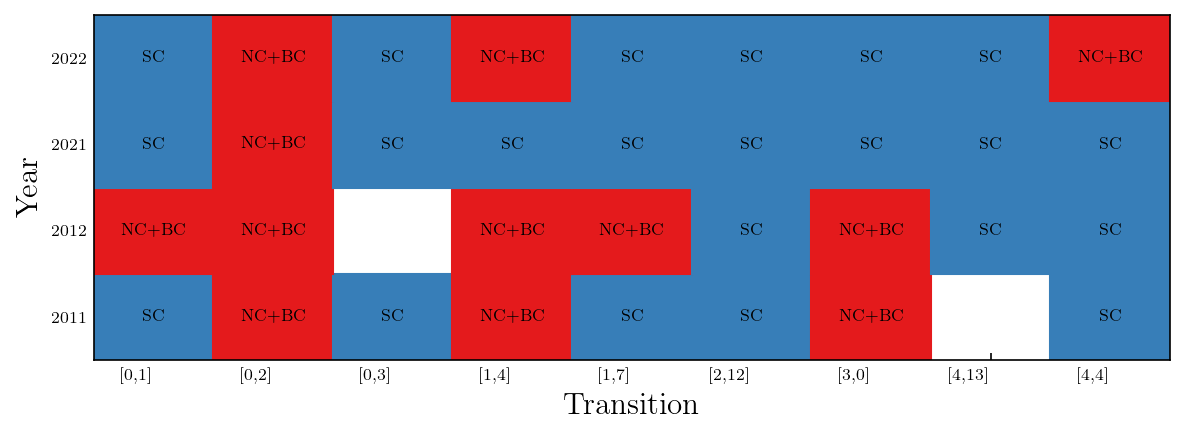

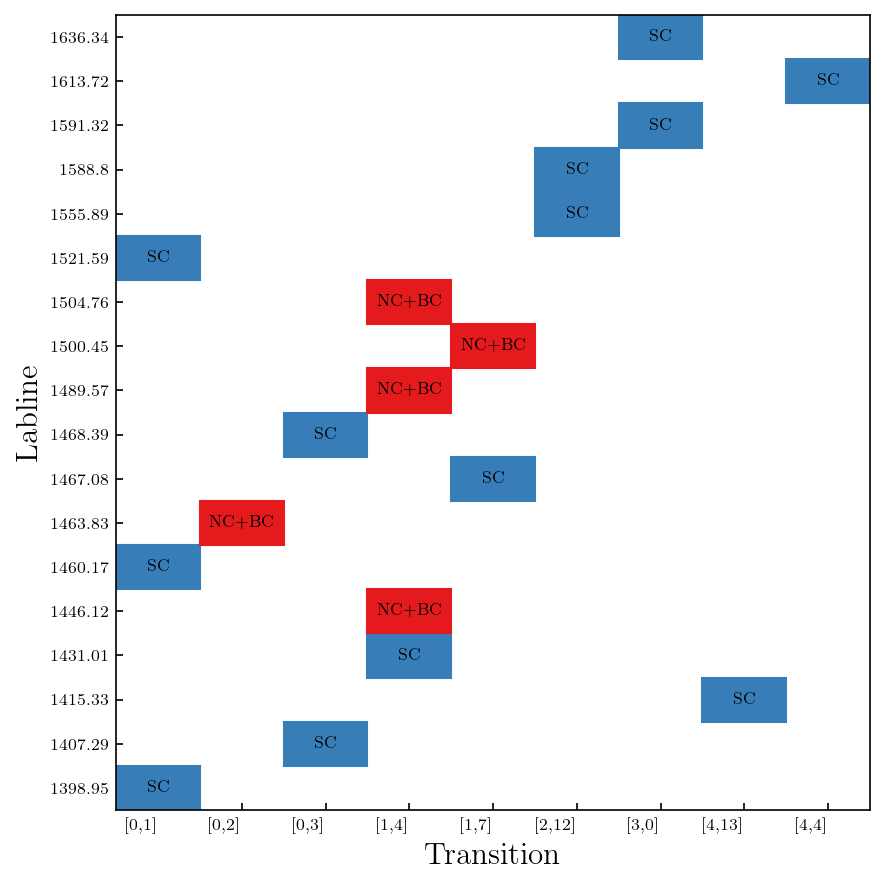

In [73]:
# Build a pivot-style grid
transitions = sorted(all_df_pruned['transition'].unique())
lablines    = sorted(all_df_pruned['labline'].unique())

# Map preference to numeric: 0=SC, 1=NC+BC, NaN=missing
def model_pref(row):
    if row['BIC2'] > row['BIC1']:
        return 0  # SC preferred
    elif row['BIC2'] < row['BIC1']:
        return 1  # NC+BC preferred
    else:
        return np.nan

all_df_pruned['pref'] = all_df_pruned.apply(model_pref, axis=1)

transitions = sorted(all_df_pruned['transition'].unique())
lablines    = sorted(all_df_pruned['labline'].unique())
years       = sorted(all_df_pruned['year'].unique())
cmap        = {0: clrs[0], 1: clrs[1]}

def draw_heatmap(ax, grid, row_labels, col_labels, row_label, col_label):
    for i in range(len(row_labels)):
        for j in range(len(col_labels)):
            val = grid[i, j]
            if not np.isnan(val):
                ax.add_patch(plt.Rectangle((j, i), 1, 1, color=cmap[int(val)]))
                ax.text(j+0.5, i+0.5, ['SC', 'NC+BC'][int(val)],
                        ha='center', va='center', fontsize=8, fontweight='bold')
    ax.set_xlim(0, len(col_labels))
    ax.set_ylim(0, len(row_labels))
    ax.set_xticks(np.arange(len(col_labels)) + 0.5)
    ax.set_xticklabels(col_labels, ha='right', fontsize=8)
    ax.set_yticks(np.arange(len(row_labels)) + 0.5)
    ax.set_yticklabels(row_labels, fontsize=8)
    ax.set_xlabel(col_label)
    ax.set_ylabel(row_label)
    ax.grid(False)

sc_patch   = mpatches.Patch(color=clrs[0], label='SC preferred')
ncbc_patch = mpatches.Patch(color=clrs[1], label='NC+BC preferred')

# --- Heatmap 1: transition vs year ---
# Majority vote across lablines for each (transition, year) combo
grid1 = np.full((len(years), len(transitions)), np.nan)
for i, year in enumerate(years):
    for j, transition in enumerate(transitions):
        subset = all_df_pruned[(all_df_pruned['year']==year) &
                               (all_df_pruned['transition']==transition)]['pref'].dropna()
        if len(subset) > 0:
            grid1[i, j] = subset.mode()[0]  # most common preference

fig1, ax1 = plt.subplots(figsize=(8,3))
draw_heatmap(ax1, grid1, years, transitions, 'Year', 'Transition')
plt.tight_layout()
plt.show()

# --- Heatmap 2: labline vs transition ---
# Majority vote across years for each (labline, transition) combo
grid2 = np.full((len(lablines), len(transitions)), np.nan)
for i, labline in enumerate(lablines):
    for j, transition in enumerate(transitions):
        subset = all_df_pruned[(all_df_pruned['labline']==labline) &
                               (all_df_pruned['transition']==transition)]['pref'].dropna()
        if len(subset) > 0:
            grid2[i, j] = subset.mode()[0]

fig2, ax2 = plt.subplots(figsize=(6,6))
draw_heatmap(ax2, grid2, lablines, transitions, 'Labline', 'Transition')
plt.tight_layout()
plt.show()

In [ ]:
plot_fits(all_df_pruned, transition='[0,3]', plot_vel=True)